In [ ]:
import pandas as pd

# load dataset
df = pd.read_csv(r"C:\Projects\anish_salary\data\ambitionbox_companies_dataset.csv")

# preview first rows
df.head()

,Name of the company,Average employee rating (out of 5) based on reviews,Total number of employee reviews,Critical Rated for,Number of salary entries submitted by employees,Count of interview experiences shared,Active job listings on AmbitionBox,"Number of benefit reviews (insurance, WFH, leaves, etc.)",Number of company photos uploaded by employees
0,TCS,3.3,1.1L,Job Security,9.7L,11.7k,3k,10.6k,87
1,Accenture,3.7,70.9k,"Promotions / Appraisal, Salary & Benefits, Wor...",6.4L,9.1k,36.6k,6.7k,48
2,Wipro,3.6,62.9k,"Promotions / Appraisal, Salary & Benefits, Wor...",4.7L,6.5k,5.7k,4.6k,99
3,Cognizant,3.6,59.8k,"Promotions / Appraisal, Salary & Benefits, Wor...",5.9L,6.3k,680,5.5k,82
4,Capgemini,3.7,51.4k,"Work Life Balance, Job Security",4.7L,5.4k,1.9k,3.6k,41


In [14]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6660 entries, 0 to 6659
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   company          6660 non-null   object 
 1   rating           6660 non-null   float64
 2   review_count     6660 non-null   float64
 3   critical_issue   6660 non-null   object 
 4   salary_count     6660 non-null   float64
 5   interview_count  6660 non-null   float64
 6   job_listings     6660 non-null   float64
 7   benefit_reviews  6660 non-null   float64
 8   photos_count     6660 non-null   float64
dtypes: float64(7), object(2)
memory usage: 468.4+ KB


,company,rating,review_count,critical_issue,salary_count,interview_count,job_listings,benefit_reviews,photos_count
0,TCS,3.3,110000.0,Job Security,970000.0,11700.0,3000.0,10600.0,87.0
1,Accenture,3.7,70900.0,"Promotions / Appraisal, Salary & Benefits, Wor...",640000.0,9100.0,36600.0,6700.0,48.0
2,Wipro,3.6,62900.0,"Promotions / Appraisal, Salary & Benefits, Wor...",470000.0,6500.0,5700.0,4600.0,99.0
3,Cognizant,3.6,59800.0,"Promotions / Appraisal, Salary & Benefits, Wor...",590000.0,6300.0,680.0,5500.0,82.0
4,Capgemini,3.7,51400.0,"Work Life Balance, Job Security",470000.0,5400.0,1900.0,3600.0,41.0


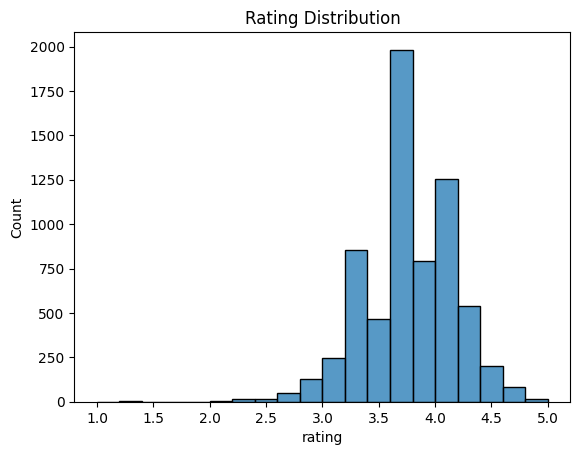

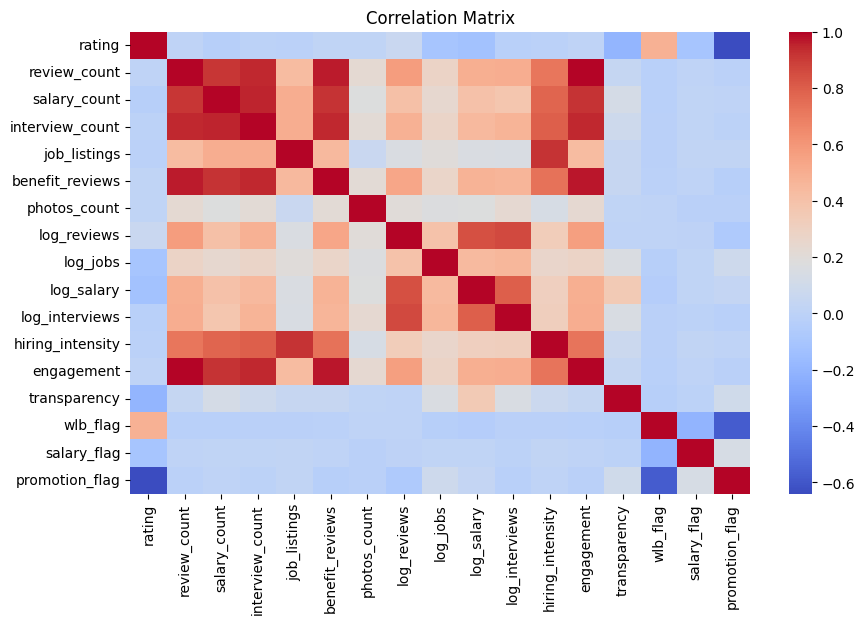

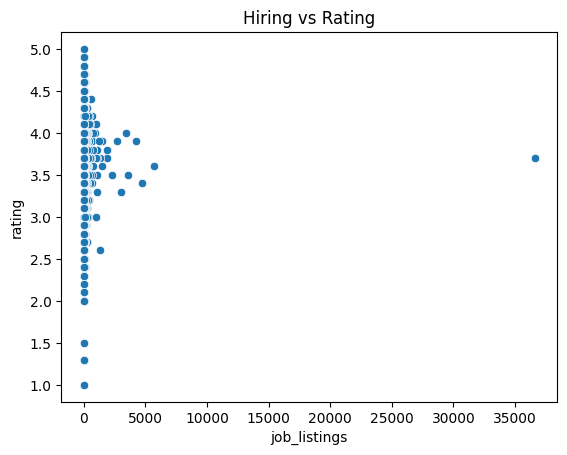


🔥 TOP COMPANIES:
          company  rating     score
1       Accenture     3.7  8.489219
0             TCS     3.3  8.000000
2           Wipro     3.6  7.991641
4       Capgemini     3.7  7.771608
6         Infosys     3.5  7.732122
19            IBM     3.9  7.618969
3       Cognizant     3.6  7.602044
15         Amazon     3.9  7.472214
22       Deloitte     3.7  7.393436
31  Ernst & Young     3.4  7.327486

📊 CLUSTER SUMMARY:
           rating  job_listings  salary_count
cluster                                      
0        3.796029      0.462526   1522.080322
1        3.697241     17.497414   1510.971983
2        3.735015    166.584258  16709.750757

🚨 HIGH HIRING BUT LOW RATING:
          company  rating  job_listings
0             TCS     3.3        3000.0
8         HCLTech     3.4         201.0
9   Tech Mahindra     3.4         388.0
28            WNS     3.3          80.0
31  Ernst & Young     3.4        4700.0
32  IndusInd Bank     3.4         144.0
37            PwC     3.3

In [2]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans


# ==============================
# 2. LOAD DATA
# ==============================
df = pd.read_csv(r"C:\Projects\anish_salary\data\ambitionbox_companies_dataset.csv")


# ==============================
# 3. CLEANING
# ==============================

# Rename columns
df.columns = [
    "company",
    "rating",
    "review_count",
    "critical_issue",
    "salary_count",
    "interview_count",
    "job_listings",
    "benefit_reviews",
    "photos_count"
]

# Fill missing values
df['rating'] = df['rating'].fillna(df['rating'].median())
df['critical_issue'] = df['critical_issue'].fillna("Unknown")


# Convert values like 1.1L, 3k → numbers
def convert_value(x):
    x = str(x).strip()
    
    if 'L' in x:
        return float(x.replace('L','')) * 100000
    elif 'k' in x:
        return float(x.replace('k','')) * 1000
    elif x == '--':
        return np.nan
    else:
        return pd.to_numeric(x, errors='coerce')


cols = [
    'review_count',
    'salary_count',
    'interview_count',
    'job_listings',
    'benefit_reviews',
    'photos_count'
]

for col in cols:
    df[col] = df[col].apply(convert_value)

# Fill remaining NaN
df = df.fillna(0)


# ==============================
# 4. FEATURE ENGINEERING
# ==============================

# Log features
df['log_reviews'] = np.log1p(df['review_count'])
df['log_jobs'] = np.log1p(df['job_listings'])
df['log_salary'] = np.log1p(df['salary_count'])
df['log_interviews'] = np.log1p(df['interview_count'])

# Derived features
df['hiring_intensity'] = df['job_listings'] + df['interview_count']
df['engagement'] = df['review_count'] + df['benefit_reviews'] + df['photos_count']
df['transparency'] = df['salary_count'] / (df['review_count'] + 1)

# NLP flags
df['wlb_flag'] = df['critical_issue'].str.contains("Work Life", case=False).astype(int)
df['salary_flag'] = df['critical_issue'].str.contains("Salary", case=False).astype(int)
df['promotion_flag'] = df['critical_issue'].str.contains("Promotion", case=False).astype(int)


# ==============================
# 5. EDA (VISUALIZATION)
# ==============================

# Rating Distribution
plt.figure()
sns.histplot(df['rating'], bins=20)
plt.title("Rating Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Hiring vs Rating
plt.figure()
sns.scatterplot(x='job_listings', y='rating', data=df)
plt.title("Hiring vs Rating")
plt.show()


# ==============================
# 6. COMPANY SCORE (CORE)
# ==============================

df['score'] = (
    df['rating'] * 0.4 +
    df['log_reviews'] * 0.2 +
    df['log_jobs'] * 0.2 +
    df['log_salary'] * 0.2
)


# ==============================
# 7. TOP COMPANIES
# ==============================

top_companies = df.sort_values(by='score', ascending=False).head(10)

print("\n🔥 TOP COMPANIES:")
print(top_companies[['company','rating','score']])


# ==============================
# 8. CLUSTERING
# ==============================

features = df[['rating','log_reviews','log_jobs','log_salary']]

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(features)

print("\n📊 CLUSTER SUMMARY:")
print(df.groupby('cluster')[['rating','job_listings','salary_count']].mean())


# ==============================
# 9. INSIGHTS
# ==============================

# Risk Companies
risk = df[
    (df['job_listings'] > df['job_listings'].median()) &
    (df['rating'] < 3.5)
]

print("\n🚨 HIGH HIRING BUT LOW RATING:")
print(risk[['company','rating','job_listings']].head(10))


# Best Companies
best = df[df['rating'] > 4].sort_values(by='score', ascending=False)

print("\n🏆 BEST COMPANIES:")
print(best[['company','rating','score']].head(10))


# ==============================
# 10. SAVE FINAL DATA
# ==============================

df.to_csv("final_processed_data.csv", index=False)

print("\n✅ Final processed data saved as 'final_processed_data.csv'")


📊 Gini Coefficient (Salary Transparency): 0.6941171954258231


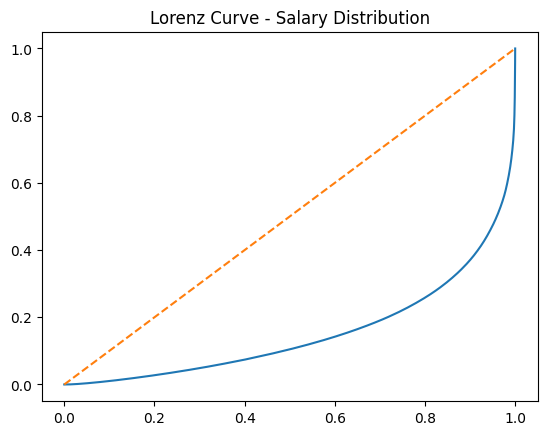

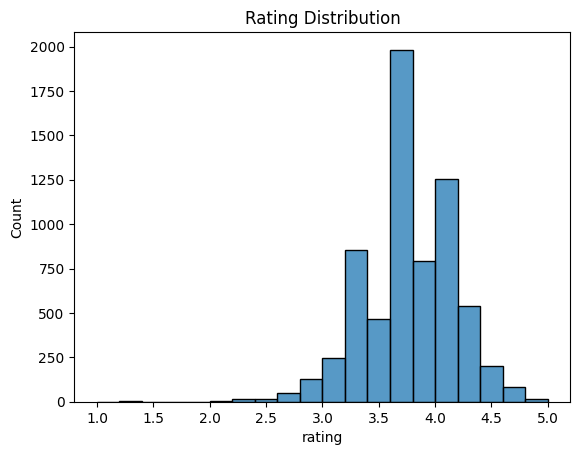

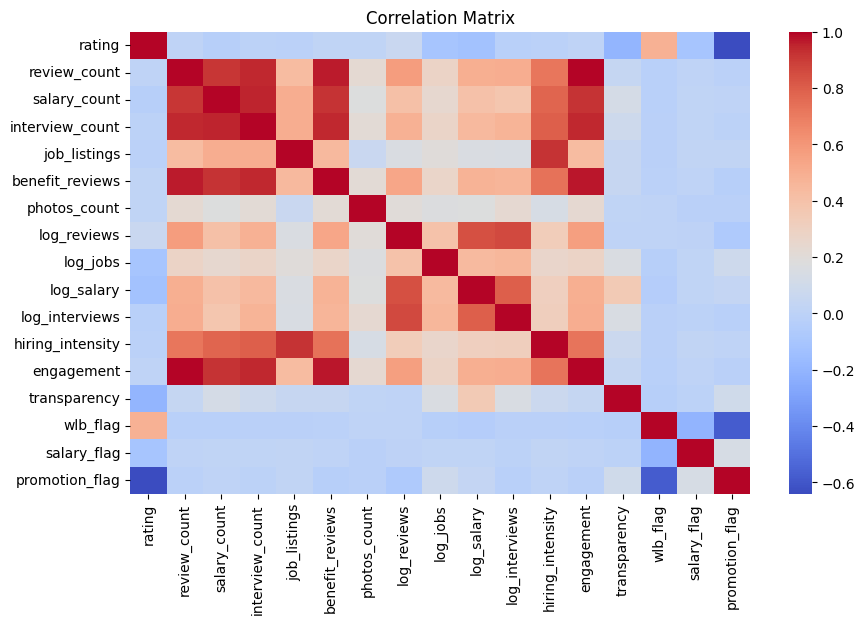


🤖 R2 Score: 0.9908126561557681

🔥 Feature Importance:
 salary_count       0.563002
job_listings       0.263722
review_count       0.104861
rating             0.048712
interview_count    0.014545
benefit_reviews    0.004203
photos_count       0.000955
dtype: float64

📊 Cluster Summary:
            rating  job_listings  salary_count     score
cluster                                                
0        3.796029      0.462526   1522.080322  4.120078
1        3.697241     17.497414   1510.971983  4.570367
2        3.735015    166.584258  16709.750757  5.556469

🚨 Risk Companies:
           company  rating  job_listings
0             TCS     3.3        3000.0
8         HCLTech     3.4         201.0
9   Tech Mahindra     3.4         388.0
28            WNS     3.3          80.0
31  Ernst & Young     3.4        4700.0
32  IndusInd Bank     3.4         144.0
37            PwC     3.3        1100.0
44        Mphasis     3.3          34.0
48        Startek     3.1         132.0
51          

In [3]:
# =========================================
# 1. IMPORTS
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score


# =========================================
# 2. LOAD DATA
# =========================================
df = pd.read_csv("C:\\Projects\\anish_salary\\data\\ambitionbox_companies_dataset.csv")


# =========================================
# 3. CLEANING
# =========================================
df.columns = [
    "company","rating","review_count","critical_issue",
    "salary_count","interview_count","job_listings",
    "benefit_reviews","photos_count"
]

df['rating'] = df['rating'].fillna(df['rating'].median())
df['critical_issue'] = df['critical_issue'].fillna("Unknown")


def convert_value(x):
    x = str(x).strip()
    if 'L' in x:
        return float(x.replace('L','')) * 100000
    elif 'k' in x:
        return float(x.replace('k','')) * 1000
    elif x == '--':
        return np.nan
    else:
        return pd.to_numeric(x, errors='coerce')


cols = [
    'review_count','salary_count','interview_count',
    'job_listings','benefit_reviews','photos_count'
]

for col in cols:
    df[col] = df[col].apply(convert_value)

df = df.fillna(0)


# =========================================
# 4. FEATURE ENGINEERING
# =========================================
df['log_reviews'] = np.log1p(df['review_count'])
df['log_jobs'] = np.log1p(df['job_listings'])
df['log_salary'] = np.log1p(df['salary_count'])
df['log_interviews'] = np.log1p(df['interview_count'])

df['hiring_intensity'] = df['job_listings'] + df['interview_count']
df['engagement'] = df['review_count'] + df['benefit_reviews'] + df['photos_count']
df['transparency'] = df['salary_count'] / (df['review_count'] + 1)

df['wlb_flag'] = df['critical_issue'].str.contains("Work Life", case=False).astype(int)
df['salary_flag'] = df['critical_issue'].str.contains("Salary", case=False).astype(int)
df['promotion_flag'] = df['critical_issue'].str.contains("Promotion", case=False).astype(int)


# =========================================
# 5. INEQUALITY ANALYSIS (Gini + Lorenz)
# =========================================
def gini(array):
    array = np.sort(array)
    n = len(array)
    index = np.arange(1, n+1)
    return (np.sum((2 * index - n - 1) * array)) / (n * np.sum(array))

gini_salary = gini(df['salary_count'] + 1)
print("\n📊 Gini Coefficient (Salary Transparency):", gini_salary)


def lorenz_curve(x):
    x = np.sort(x)
    cum = np.cumsum(x)
    cum = np.insert(cum, 0, 0)
    return cum / cum[-1]

lorenz = lorenz_curve(df['salary_count'] + 1)

plt.figure()
plt.plot(np.linspace(0,1,len(lorenz)), lorenz)
plt.plot([0,1],[0,1], linestyle='--')
plt.title("Lorenz Curve - Salary Distribution")
plt.show()


# =========================================
# 6. EDA
# =========================================
plt.figure()
sns.histplot(df['rating'], bins=20)
plt.title("Rating Distribution")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


# =========================================
# 7. COMPANY SCORE
# =========================================
df['score'] = (
    df['rating'] * 0.4 +
    df['log_reviews'] * 0.2 +
    df['log_jobs'] * 0.2 +
    df['log_salary'] * 0.2
)


# =========================================
# 8. ML MODEL (PREDICTION)
# =========================================
features = [
    'rating','review_count','salary_count',
    'interview_count','job_listings',
    'benefit_reviews','photos_count'
]

X = df[features]
y = df['score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("\n🤖 R2 Score:", r2_score(y_test, pred))


# Feature Importance
importances = pd.Series(model.feature_importances_, index=features)
print("\n🔥 Feature Importance:\n", importances.sort_values(ascending=False))


# =========================================
# 9. CLUSTERING
# =========================================
cluster_features = df[['rating','log_reviews','log_jobs','log_salary']]

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(cluster_features)

cluster_summary = df.groupby('cluster')[['rating','job_listings','salary_count','score']].mean()
print("\n📊 Cluster Summary:\n", cluster_summary)


# Label clusters
def label_cluster(row):
    if row['rating'] > 3.8 and row['job_listings'] > 1000:
        return "Top Companies"
    elif row['rating'] < 3.5 and row['job_listings'] > 1000:
        return "High Risk"
    else:
        return "Average"

df['cluster_label'] = df.apply(label_cluster, axis=1)


# =========================================
# 10. INSIGHTS
# =========================================
risk = df[
    (df['job_listings'] > df['job_listings'].median()) &
    (df['rating'] < 3.5)
]

print("\n🚨 Risk Companies:\n", risk[['company','rating','job_listings']].head(10))

best = df[df['rating'] > 4].sort_values(by='score', ascending=False)

print("\n🏆 Best Companies:\n", best[['company','rating','score']].head(10))


# =========================================
# 11. SAVE FINAL DATA
# =========================================
df.to_csv("final_processed_data.csv", index=False)

print("\n✅ Final dataset saved: final_processed_data.csv")

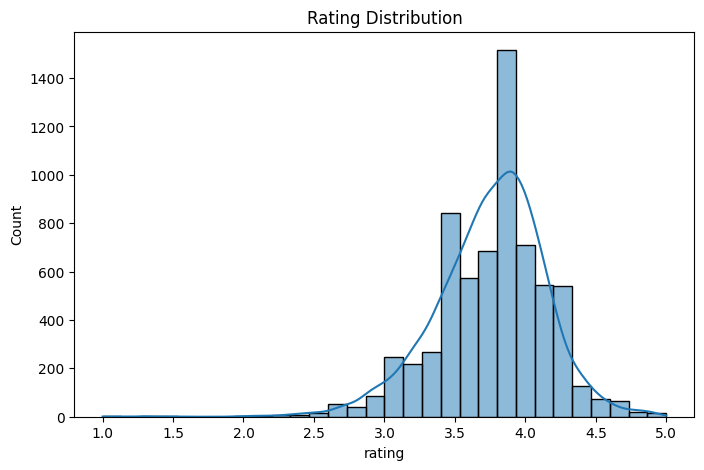

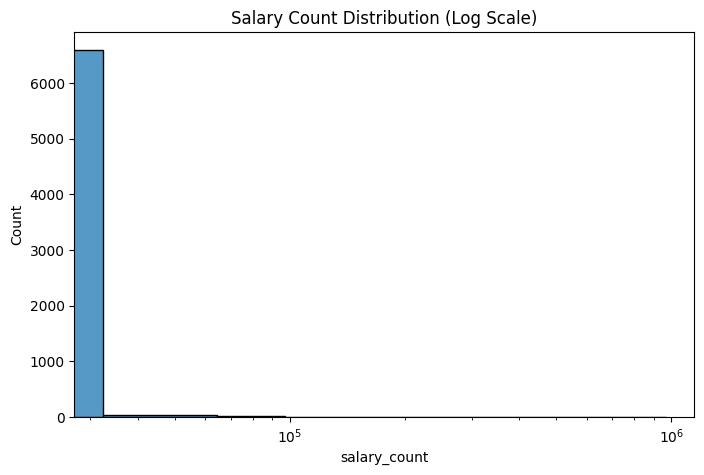

ValueError: Bin edges must be unique: Index([0.0, 0.0, 1.0, 6.0, 19.0, 36600.0], dtype='float64', name='job_listings').
You can drop duplicate edges by setting the 'duplicates' kwarg

In [7]:
# =========================================
# 1. IMPORTS
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8,5)


# =========================================
# 2. LOAD DATA
# =========================================
df = pd.read_csv("C:\\Projects\\anish_salary\\data\\ambitionbox_companies_dataset.csv")


# =========================================
# 3. CLEANING
# =========================================
df.columns = [
    "company","rating","review_count","critical_issue",
    "salary_count","interview_count","job_listings",
    "benefit_reviews","photos_count"
]

df['rating'] = df['rating'].fillna(df['rating'].median())
df['critical_issue'] = df['critical_issue'].fillna("Unknown")


def convert_value(x):
    x = str(x).strip()
    if 'L' in x:
        return float(x.replace('L','')) * 100000
    elif 'k' in x:
        return float(x.replace('k','')) * 1000
    elif x == '--':
        return np.nan
    else:
        return pd.to_numeric(x, errors='coerce')


cols = [
    'review_count','salary_count','interview_count',
    'job_listings','benefit_reviews','photos_count'
]

for col in cols:
    df[col] = df[col].apply(convert_value)

df = df.fillna(0)


# =========================================
# 4. FEATURE ENGINEERING (LIGHT)
# =========================================
df['engagement'] = df['review_count'] + df['benefit_reviews'] + df['photos_count']
df['transparency'] = df['salary_count'] / (df['review_count'] + 1)

df['log_reviews'] = np.log1p(df['review_count'])
df['log_jobs'] = np.log1p(df['job_listings'])


# =========================================
# 5. DISTRIBUTION ANALYSIS
# =========================================
sns.histplot(df['rating'], bins=30, kde=True)
plt.title("Rating Distribution")
plt.show()

sns.histplot(df['salary_count'], bins=30)
plt.xscale('log')
plt.title("Salary Count Distribution (Log Scale)")
plt.show()


# =========================================
# 6. BOXPLOT ANALYSIS
# =========================================
df['job_bins'] = pd.qcut(df['job_listings'], 5)

sns.boxplot(x='job_bins', y='rating', data=df)
plt.xticks(rotation=45)
plt.title("Rating vs Hiring Levels")
plt.show()


# =========================================
# 7. SCATTER RELATIONSHIPS
# =========================================
sns.scatterplot(x='salary_count', y='rating', data=df)
plt.title("Salary Transparency vs Rating")
plt.show()

sns.scatterplot(x='review_count', y='rating', data=df)
plt.title("Reviews vs Rating")
plt.show()


# =========================================
# 8. CORRELATION HEATMAP
# =========================================
features = [
    'rating','review_count','salary_count',
    'job_listings','interview_count','benefit_reviews'
]

sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm')
plt.title("Key Feature Correlations")
plt.show()


# =========================================
# 9. PAIRPLOT (RELATION MATRIX)
# =========================================
sns.pairplot(df[features].sample(1000))
plt.show()


# =========================================
# 10. TOP COMPANIES
# =========================================
top = df.sort_values(by='rating', ascending=False).head(20)

sns.barplot(y='company', x='rating', data=top)
plt.title("Top Rated Companies")
plt.show()


# =========================================
# 11. LOW RATED COMPANIES
# =========================================
low = df.sort_values(by='rating').head(20)

sns.barplot(y='company', x='rating', data=low)
plt.title("Lowest Rated Companies")
plt.show()


# =========================================
# 12. MULTI-VARIABLE SCATTER
# =========================================
sns.scatterplot(
    x='job_listings',
    y='rating',
    size='salary_count',
    hue='benefit_reviews',
    data=df
)
plt.title("Hiring vs Rating (Size=Salary, Color=Benefits)")
plt.show()


# =========================================
# 13. ENGAGEMENT VS RATING
# =========================================
sns.scatterplot(x='engagement', y='rating', data=df)
plt.title("Engagement vs Rating")
plt.show()


# =========================================
# 14. CRITICAL ISSUE ANALYSIS
# =========================================
df['critical_issue'].value_counts().head(10).plot(kind='bar')
plt.title("Top Critical Issues")
plt.show()


# =========================================
# 15. ISSUE VS RATING
# =========================================
issue_group = df.groupby('critical_issue')['rating'].mean().sort_values()

issue_group.head(10).plot(kind='barh')
plt.title("Lowest Rated Issues")
plt.show()


# =========================================
# 16. HIRING VS TRANSPARENCY
# =========================================
sns.scatterplot(x='job_listings', y='salary_count', data=df)
plt.title("Hiring vs Salary Transparency")
plt.show()


# =========================================
# 17. LOG RELATIONSHIP
# =========================================
sns.scatterplot(x='log_reviews', y='rating', data=df)
plt.title("Log Reviews vs Rating")
plt.show()


# =========================================
# 18. SAVE CLEAN DATA
# =========================================
df.to_csv("final_cleaned_analysis.csv", index=False)

print("✅ Analysis complete. Data saved.")

In [6]:
df['job_bins'] = pd.qcut(df['job_listings'], 5, duplicates='drop')

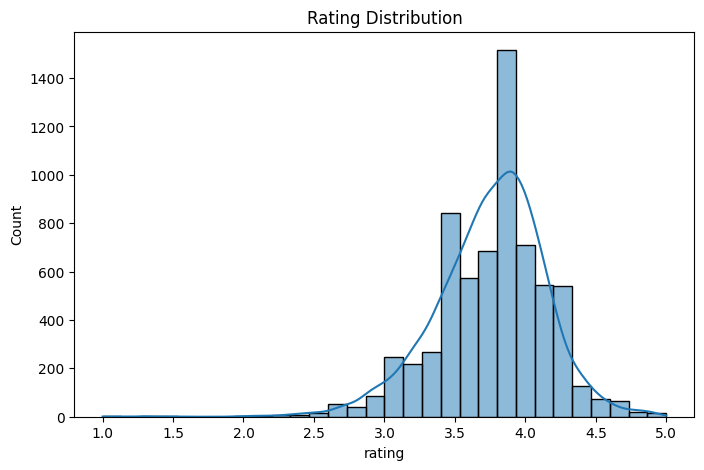

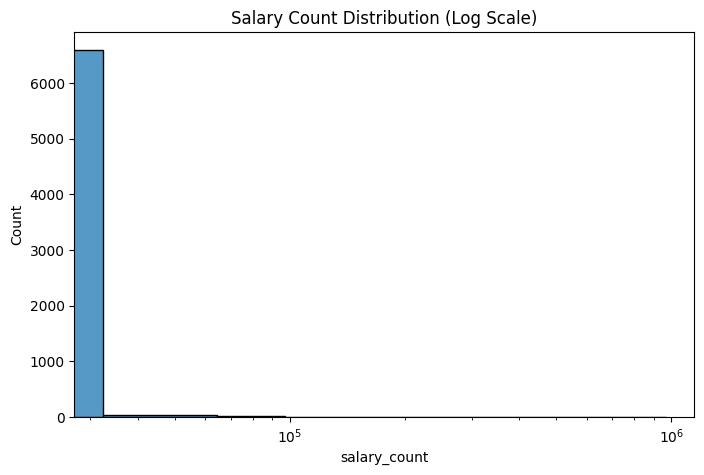

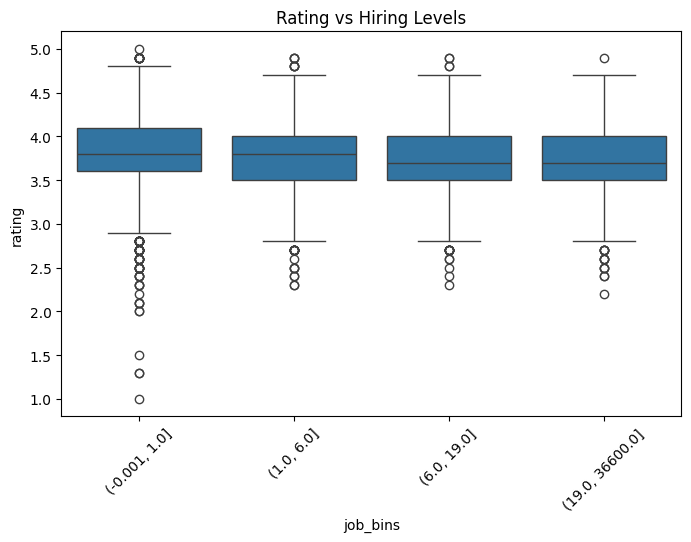

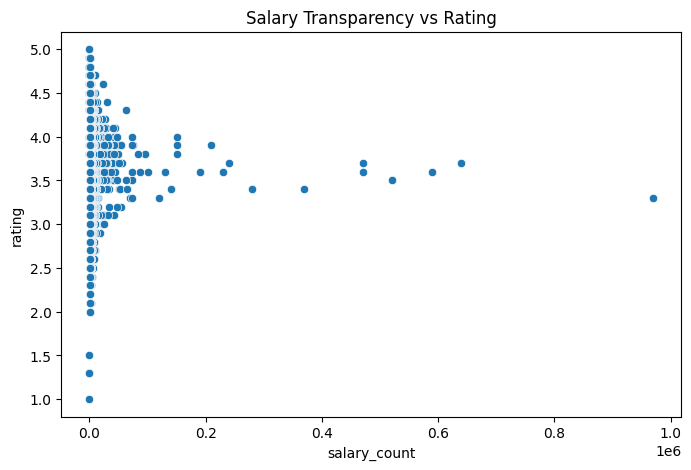

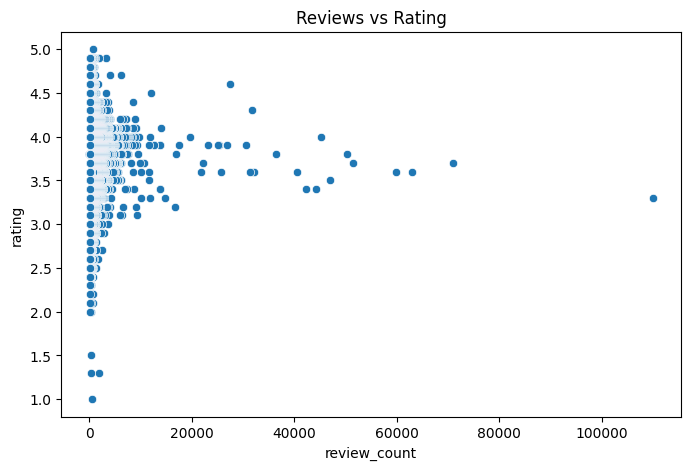

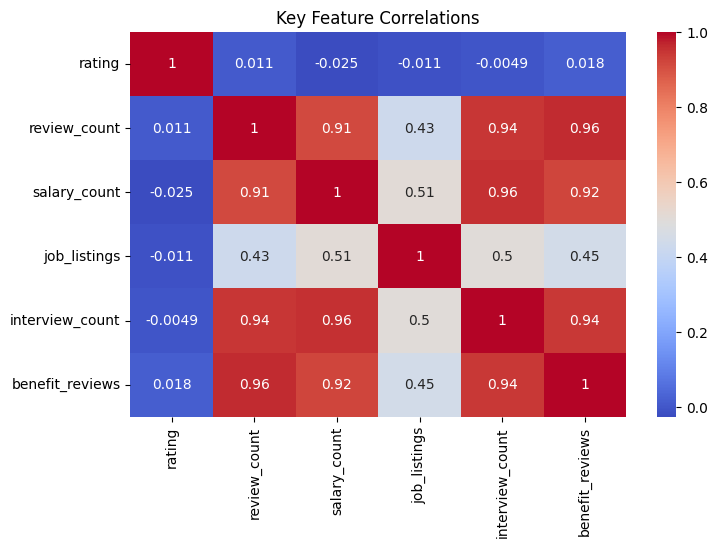

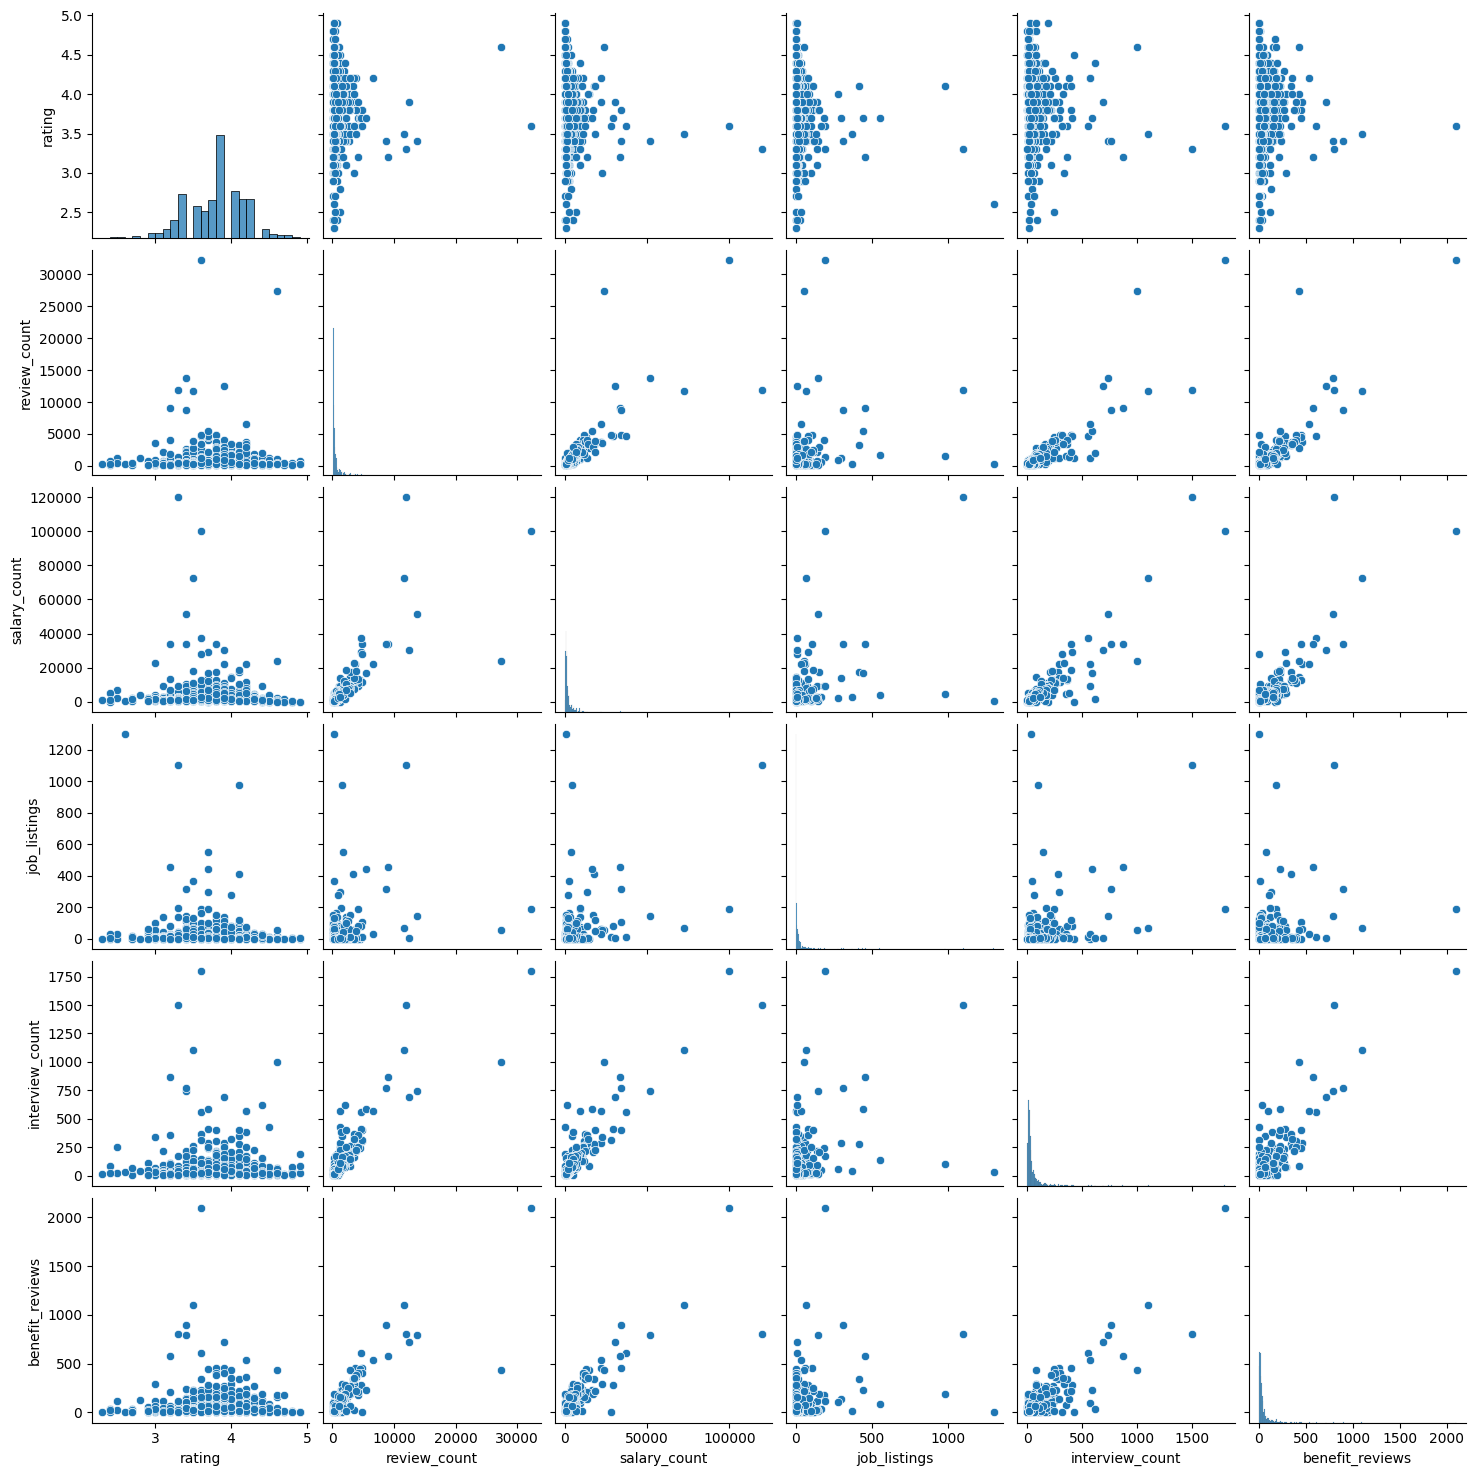

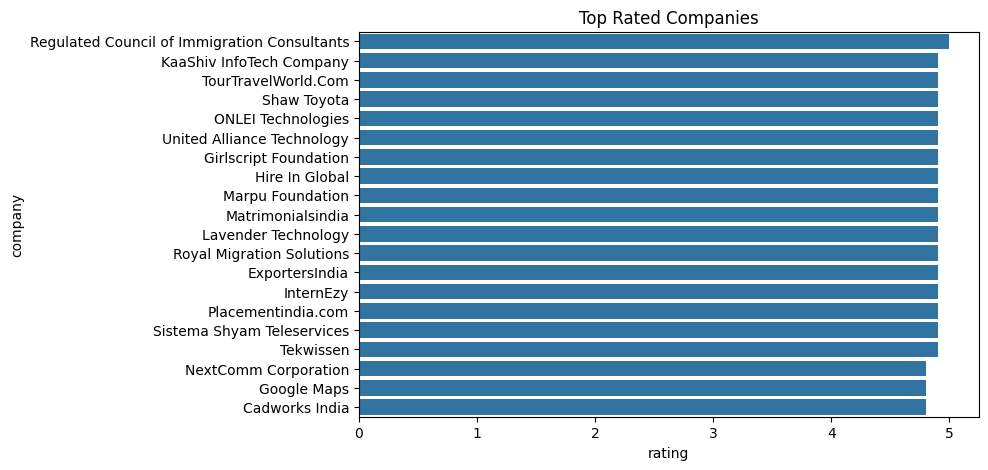

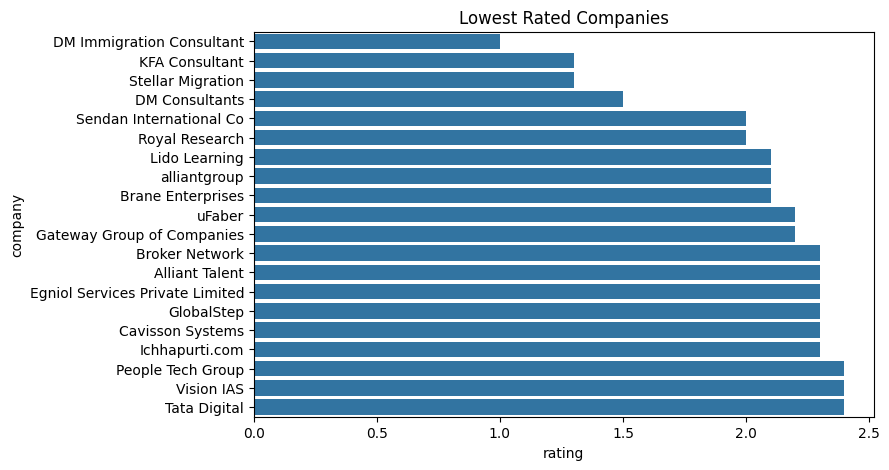

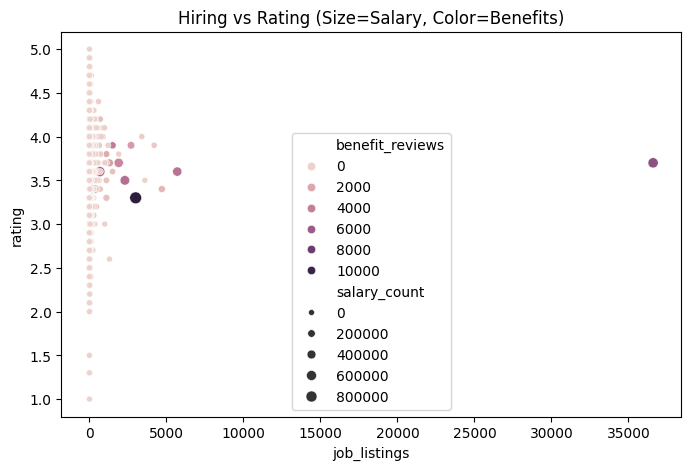

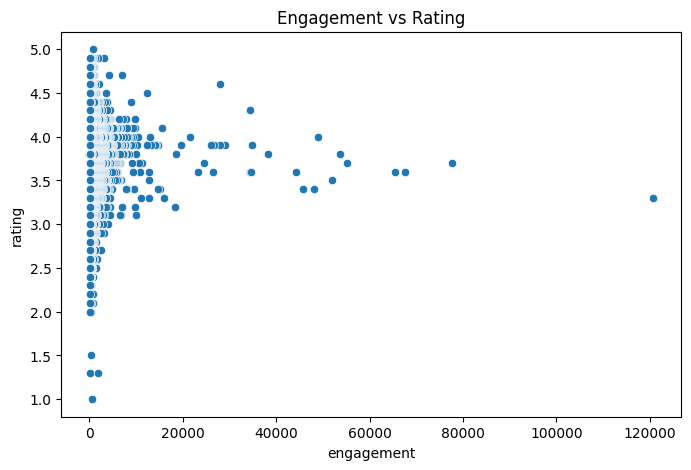

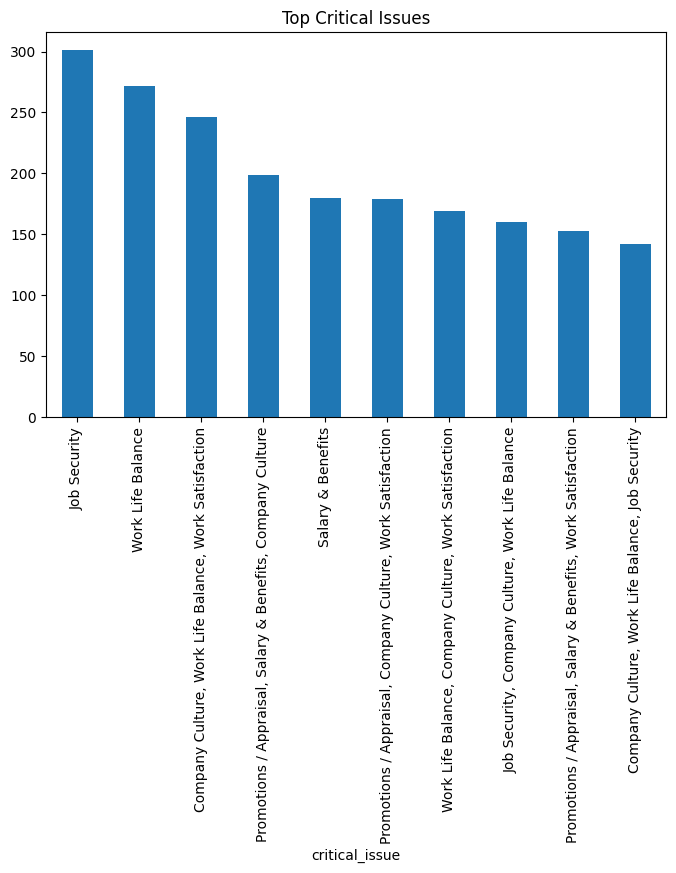

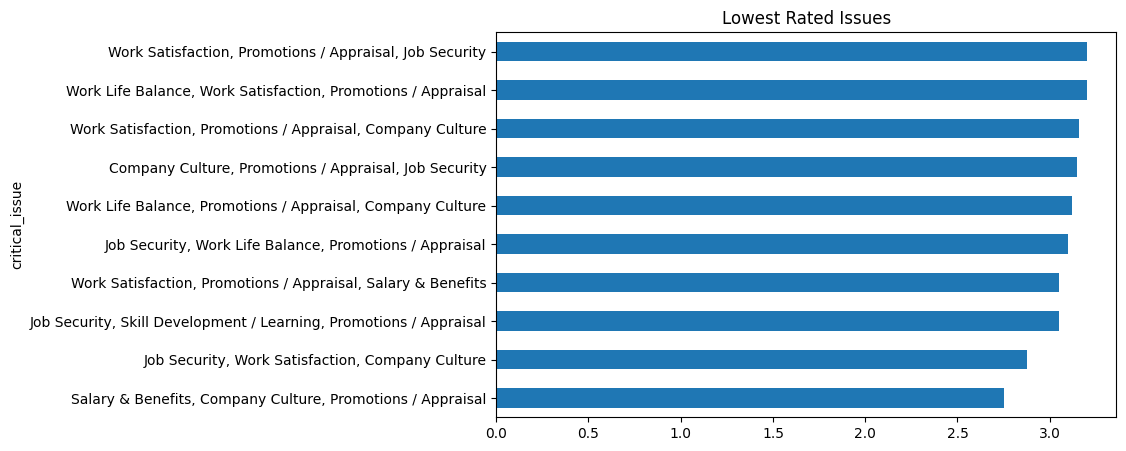

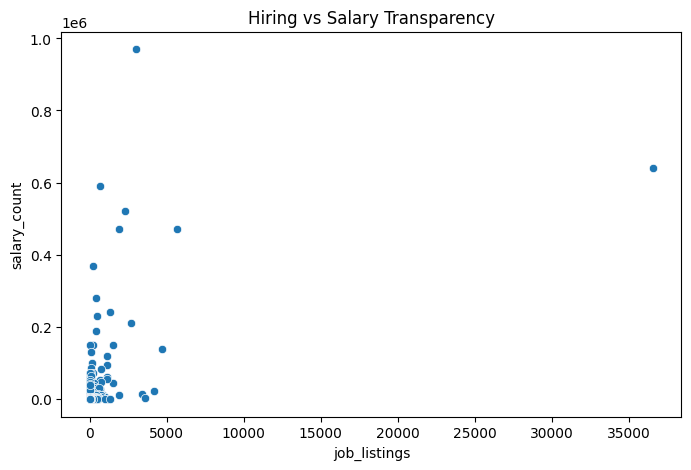

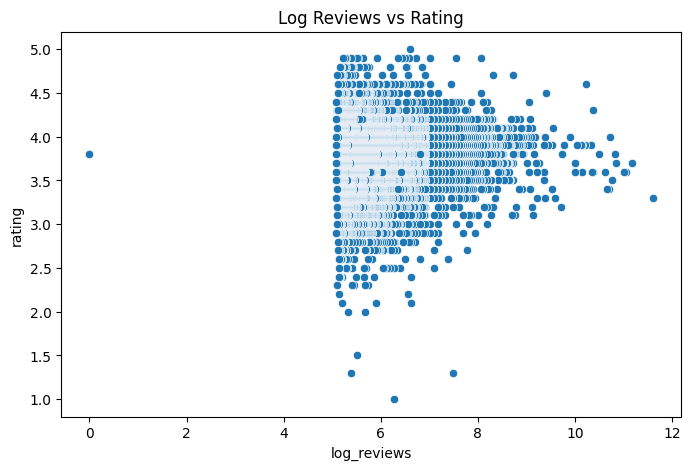

✅ Analysis complete. Data saved.


In [9]:
# =========================================
# 1. IMPORTS
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8,5)


# =========================================
# 2. LOAD DATA
# =========================================
df = pd.read_csv("C:\\Projects\\anish_salary\\data\\ambitionbox_companies_dataset.csv")


# =========================================
# 3. CLEANING
# =========================================
df.columns = [
    "company","rating","review_count","critical_issue",
    "salary_count","interview_count","job_listings",
    "benefit_reviews","photos_count"
]

df['rating'] = df['rating'].fillna(df['rating'].median())
df['critical_issue'] = df['critical_issue'].fillna("Unknown")


def convert_value(x):
    x = str(x).strip()
    if 'L' in x:
        return float(x.replace('L','')) * 100000
    elif 'k' in x:
        return float(x.replace('k','')) * 1000
    elif x == '--':
        return np.nan
    else:
        return pd.to_numeric(x, errors='coerce')


cols = [
    'review_count','salary_count','interview_count',
    'job_listings','benefit_reviews','photos_count'
]

for col in cols:
    df[col] = df[col].apply(convert_value)

df = df.fillna(0)


# =========================================
# 4. FEATURE ENGINEERING (LIGHT)
# =========================================
df['engagement'] = df['review_count'] + df['benefit_reviews'] + df['photos_count']
df['transparency'] = df['salary_count'] / (df['review_count'] + 1)

df['log_reviews'] = np.log1p(df['review_count'])
df['log_jobs'] = np.log1p(df['job_listings'])


# =========================================
# 5. DISTRIBUTION ANALYSIS
# =========================================
sns.histplot(df['rating'], bins=30, kde=True)
plt.title("Rating Distribution")
plt.show()

sns.histplot(df['salary_count'], bins=30)
plt.xscale('log')
plt.title("Salary Count Distribution (Log Scale)")
plt.show()


# =========================================
# 6. BOXPLOT ANALYSIS
# =========================================
df['job_bins'] = pd.qcut(df['job_listings'], 5, duplicates='drop')

sns.boxplot(x='job_bins', y='rating', data=df)
plt.xticks(rotation=45)
plt.title("Rating vs Hiring Levels")
plt.show()


# =========================================
# 7. SCATTER RELATIONSHIPS
# =========================================
sns.scatterplot(x='salary_count', y='rating', data=df)
plt.title("Salary Transparency vs Rating")
plt.show()

sns.scatterplot(x='review_count', y='rating', data=df)
plt.title("Reviews vs Rating")
plt.show()


# =========================================
# 8. CORRELATION HEATMAP
# =========================================
features = [
    'rating','review_count','salary_count',
    'job_listings','interview_count','benefit_reviews'
]

sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm')
plt.title("Key Feature Correlations")
plt.show()


# =========================================
# 9. PAIRPLOT (RELATION MATRIX)
# =========================================
sns.pairplot(df[features].sample(1000))
plt.show()


# =========================================
# 10. TOP COMPANIES
# =========================================
top = df.sort_values(by='rating', ascending=False).head(20)

sns.barplot(y='company', x='rating', data=top)
plt.title("Top Rated Companies")
plt.show()


# =========================================
# 11. LOW RATED COMPANIES
# =========================================
low = df.sort_values(by='rating').head(20)

sns.barplot(y='company', x='rating', data=low)
plt.title("Lowest Rated Companies")
plt.show()


# =========================================
# 12. MULTI-VARIABLE SCATTER
# =========================================
sns.scatterplot(
    x='job_listings',
    y='rating',
    size='salary_count',
    hue='benefit_reviews',
    data=df
)
plt.title("Hiring vs Rating (Size=Salary, Color=Benefits)")
plt.show()


# =========================================
# 13. ENGAGEMENT VS RATING
# =========================================
sns.scatterplot(x='engagement', y='rating', data=df)
plt.title("Engagement vs Rating")
plt.show()


# =========================================
# 14. CRITICAL ISSUE ANALYSIS
# =========================================
df['critical_issue'].value_counts().head(10).plot(kind='bar')
plt.title("Top Critical Issues")
plt.show()


# =========================================
# 15. ISSUE VS RATING
# =========================================
issue_group = df.groupby('critical_issue')['rating'].mean().sort_values()

issue_group.head(10).plot(kind='barh')
plt.title("Lowest Rated Issues")
plt.show()


# =========================================
# 16. HIRING VS TRANSPARENCY
# =========================================
sns.scatterplot(x='job_listings', y='salary_count', data=df)
plt.title("Hiring vs Salary Transparency")
plt.show()


# =========================================
# 17. LOG RELATIONSHIP
# =========================================
sns.scatterplot(x='log_reviews', y='rating', data=df)
plt.title("Log Reviews vs Rating")
plt.show()


# =========================================
# 18. SAVE CLEAN DATA
# =========================================
df.to_csv("final_cleaned_analysis.csv", index=False)

print("✅ Analysis complete. Data saved.")

In [ ]:
# =========================================
# 1. IMPORTS
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.rcParams["figure.figsize"] = (8,5)


# =========================================
# 2. CREATE FOLDERS
# =========================================
os.makedirs("output/images", exist_ok=True)
os.makedirs("output/plots", exist_ok=True)


# =========================================
# 3. LOAD DATA
# =========================================
df = pd.read_csv("C:/Projects/anish_salary/data/ambitionbox_companies_dataset.csv")


# =========================================
# 4. CLEANING
# =========================================
df.columns = [
    "company","rating","review_count","critical_issue",
    "salary_count","interview_count","job_listings",
    "benefit_reviews","photos_count"
]

df['rating'] = df['rating'].fillna(df['rating'].median())
df['critical_issue'] = df['critical_issue'].fillna("Unknown")


def convert_value(x):
    x = str(x).strip()
    if 'L' in x:
        return float(x.replace('L','')) * 100000
    elif 'k' in x:
        return float(x.replace('k','')) * 1000
    elif x == '--':
        return np.nan
    else:
        return pd.to_numeric(x, errors='coerce')


cols = [
    'review_count','salary_count','interview_count',
    'job_listings','benefit_reviews','photos_count'
]

for col in cols:
    df[col] = df[col].apply(convert_value)

df = df.fillna(0)


# =========================================
# 5. FEATURE ENGINEERING
# =========================================
df['engagement'] = df['review_count'] + df['benefit_reviews'] + df['photos_count']
df['transparency'] = df['salary_count'] / (df['review_count'] + 1)

df['log_reviews'] = np.log1p(df['review_count'])
df['log_jobs'] = np.log1p(df['job_listings'])


# =========================================
# 6. DISTRIBUTION PLOTS
# =========================================
plt.figure()
sns.histplot(df['rating'], bins=30, kde=True)
plt.title("Rating Distribution")
plt.savefig("output/plots/rating_distribution.png")
plt.close()

plt.figure()
sns.histplot(df['salary_count'], bins=30)
plt.xscale('log')
plt.title("Salary Distribution (Log Scale)")
plt.savefig("output/plots/salary_distribution_log.png")
plt.close()


# =========================================
# 7. BOXPLOT (FIXED BINS)
# =========================================
df['job_bins'] = pd.cut(
    df['job_listings'],
    bins=[-1, 0, 10, 100, 1000, 10000, df['job_listings'].max()],
    labels=["0", "1-10", "10-100", "100-1K", "1K-10K", "10K+"]
)

plt.figure()
sns.boxplot(x='job_bins', y='rating', data=df)
plt.xticks(rotation=45)
plt.title("Rating vs Hiring Levels")
plt.savefig("output/plots/rating_vs_hiring_boxplot.png")
plt.close()


# =========================================
# 8. SCATTER RELATIONSHIPS
# =========================================
plt.figure()
sns.scatterplot(x='salary_count', y='rating', data=df)
plt.title("Salary vs Rating")
plt.savefig("output/plots/salary_vs_rating.png")
plt.close()

plt.figure()
sns.scatterplot(x='review_count', y='rating', data=df)
plt.title("Reviews vs Rating")
plt.savefig("output/plots/reviews_vs_rating.png")
plt.close()


# =========================================
# 9. HEATMAP
# =========================================
features = [
    'rating','review_count','salary_count',
    'job_listings','interview_count','benefit_reviews'
]

plt.figure(figsize=(10,6))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("output/plots/correlation_heatmap.png")
plt.close()


# =========================================
# 10. TOP COMPANIES
# =========================================
top = df.sort_values(by='rating', ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(y='company', x='rating', data=top)
plt.title("Top Rated Companies")
plt.savefig("output/images/top_companies.png")
plt.close()


# =========================================
# 11. LOW COMPANIES
# =========================================
low = df.sort_values(by='rating').head(20)

plt.figure(figsize=(10,6))
sns.barplot(y='company', x='rating', data=low)
plt.title("Lowest Rated Companies")
plt.savefig("output/images/low_companies.png")
plt.close()


# =========================================
# 12. MULTI SCATTER
# =========================================
plt.figure()
sns.scatterplot(
    x='job_listings',
    y='rating',
    size='salary_count',
    hue='benefit_reviews',
    data=df
)
plt.title("Hiring vs Rating (Multi-variable)")
plt.savefig("output/plots/multivariable_scatter.png")
plt.close()


# =========================================
# 13. ENGAGEMENT
# =========================================
plt.figure()
sns.scatterplot(x='engagement', y='rating', data=df)
plt.title("Engagement vs Rating")
plt.savefig("output/plots/engagement_vs_rating.png")
plt.close()


# =========================================
# 14. CRITICAL ISSUE
# =========================================
plt.figure()
df['critical_issue'].value_counts().head(10).plot(kind='bar')
plt.title("Top Issues")
plt.savefig("output/images/top_issues.png")
plt.close()


# =========================================
# 15. ISSUE vs RATING
# =========================================
issue_group = df.groupby('critical_issue')['rating'].mean().sort_values()

plt.figure()
issue_group.head(10).plot(kind='barh')
plt.title("Lowest Rated Issues")
plt.savefig("output/images/issues_vs_rating.png")
plt.close()


# =========================================
# 16. SAVE INSIGHTS
# =========================================
with open("output/insights.txt", "w") as f:
    f.write("Key Insights:\n")
    f.write("- Higher hiring does not guarantee better ratings\n")
    f.write("- Salary transparency has weak correlation with satisfaction\n")
    f.write("- Some issues strongly reduce company ratings\n")
    f.write("- Engagement slightly improves rating\n")


# =========================================
# DONE
# =========================================
print("✅ All plots saved in /output folder")